# Comparing Different Search Strategies: Maze

Notes on breaking ties: 

* The order in which the children are explored (see `available directions`) makes a big difference for DFS and dealing with empty spaces. I explore the directions in random order which makes the algorithm stochastic!
* Ties for $h(n)$ and $f(n)$ need to be broken in a consistent manner. I use the most recently added node. To try to keep moving into the same direction.



Helper functions for the Maze Assignment by M. Hahsler
Usage: 
  import maze_helper as mh
  mh.show_some_mazes()
  
Here is an example maze:

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX

The goal is at (np.int64(8), np.int64(1)).
Position(0,0): X
Position(8,1):  


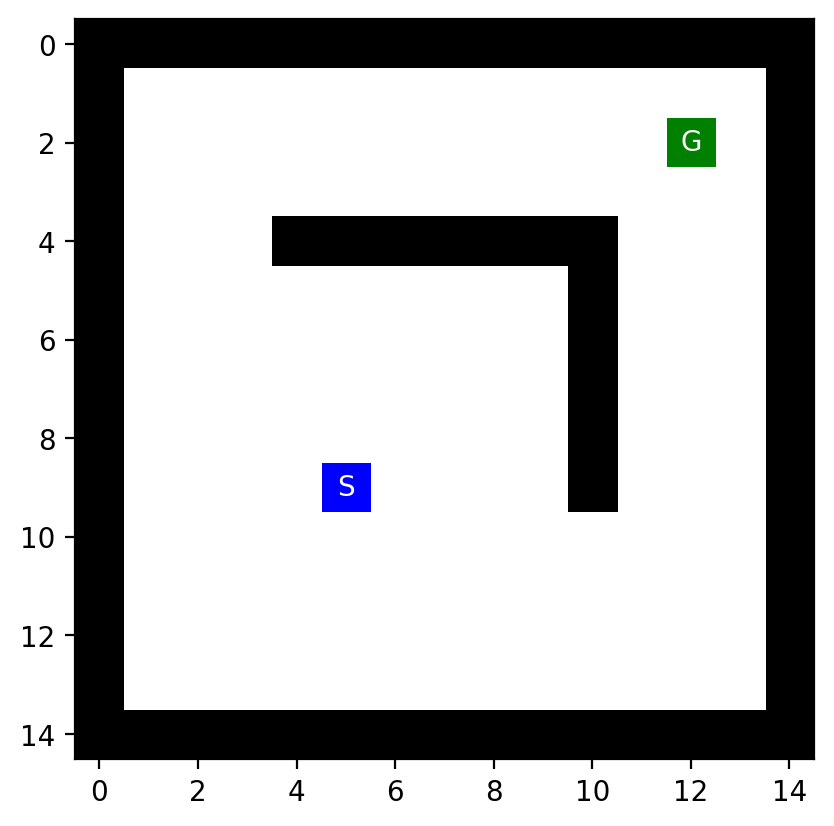

In [1]:
%run maze_helper.py
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np

#f = open("small_maze.txt", "r")
#f = open("medium_maze.txt", "r")
#f = open("large_maze.txt", "r")    # this has only one solution!
#f = open("open_maze.txt", "r")
#f = open("empty_maze.txt", "r")
#f = open("empty_maze_2.txt", "r")
#f = open("loops_maze.txt", "r")
f = open("L_maze.txt", "r")

maze_str = f.read()
maze = parse_maze(maze_str)

# look at two positions in the maze
print("Position(0,0):", maze[0, 0])
print("Position(8,1):", maze[8, 1])

show_maze(maze)

## Implementation

My implementation follows the pseudo code from the slides/textbook.

In [2]:
# tree_search_solution.py has my actual implementation (not published)
import tree_search_solution as ts


# order in which we add new states to the frontier
ts.set_order("NESW")
#ts.set_order(random=True)

Directions are checked in the order ['N', 'E', 'S', 'W']


## Experiments

### BFS

Directions are checked in the order ['N', 'E', 'S', 'W']
CPU times: total: 0 ns
Wall time: 1.23 ms
Path length: 16
Reached squares: 152


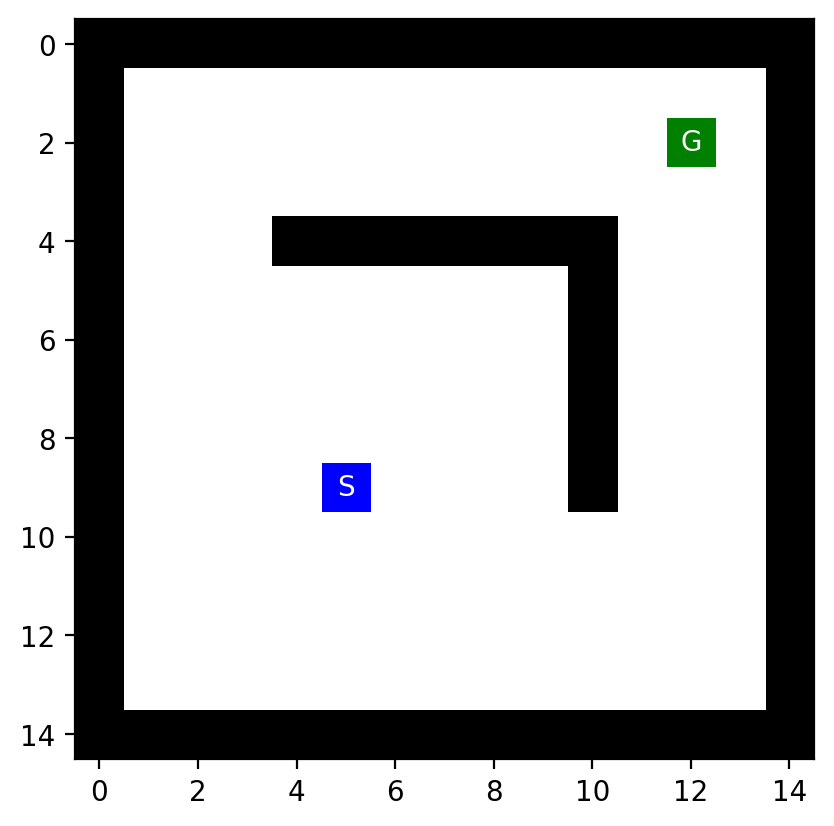

Path: [(np.int64(9), np.int64(5)), (np.int64(9), np.int64(6)), (np.int64(9), np.int64(7)), (np.int64(9), np.int64(8)), (np.int64(9), np.int64(9)), (np.int64(10), np.int64(9)), (np.int64(10), np.int64(10)), (np.int64(10), np.int64(11)), (np.int64(9), np.int64(11)), (np.int64(8), np.int64(11)), (np.int64(7), np.int64(11)), (np.int64(6), np.int64(11)), (np.int64(5), np.int64(11)), (np.int64(4), np.int64(11)), (np.int64(3), np.int64(11)), (np.int64(2), np.int64(11)), (np.int64(2), np.int64(12))]
Actions: ['E', 'E', 'E', 'E', 'S', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'E']


['E',
 'E',
 'E',
 'E',
 'S',
 'E',
 'E',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'N',
 'E']

In [3]:
ts.set_order("NESW")
#ts.set_order(random=True)

%time result = ts.best_first_search(maze, strategy = "BFS", debug = False, vis = False)
ts.show_path(maze, result)
result['actions']

### BÀI 3 - SO SÁNH BFS VÀ DFS

In [4]:
ts.set_order("NESW")

result_bfs = ts.best_first_search(
    maze, strategy="BFS", debug=False, vis=False
)

result_dfs = ts.best_first_search(
    maze, strategy="DFS", debug=False, vis=False
)

for name, result in [("BFS", result_bfs), ("DFS", result_dfs)]:
    print(f"\n===== {name} =====")

    actions = result.get("actions")

    print("Path length:", len(actions) if actions is not None else "No solution")
    print("Reached squares:", len(result["reached"]))
    print("Expanded count:", result.get("expanded_count", "Chưa có"))
    print("Max frontier:", result.get("max_frontier", "Chưa có"))

Directions are checked in the order ['N', 'E', 'S', 'W']

===== BFS =====
Path length: 16
Reached squares: 152
Expanded count: 151
Max frontier: 17

===== DFS =====
Path length: 122
Reached squares: 133
Expanded count: 132
Max frontier: 109


### BÀI 3 - ĐO THỜI GIAN BFS VÀ DFS

In [5]:
import time
import numpy as np

with open("L_maze.txt", "r") as f:
    maze = parse_maze(f.read())

ts.set_order("NESW")

for algorithm in ["BFS", "DFS"]:
    times = []

    for i in range(30):
        start = time.perf_counter()

        result = ts.best_first_search(
            maze,
            strategy=algorithm,
            debug=False,
            vis=False
        )

        elapsed = (time.perf_counter() - start) * 1000
        times.append(elapsed)

    print(f"\n===== {algorithm} =====")
    print(f"Average time: {np.mean(times):.3f} ms")
    print("Path length:", len(result["actions"]))
    print("Expanded count:", result["expanded_count"])
    print("Max frontier:", result["max_frontier"])

Directions are checked in the order ['N', 'E', 'S', 'W']

===== BFS =====
Average time: 1.092 ms
Path length: 16
Expanded count: 151
Max frontier: 17

===== DFS =====
Average time: 1.702 ms
Path length: 122
Expanded count: 132
Max frontier: 109


### BÀI 3 - THỰC NGHIỆM DFS NGẪU NHIÊN

In [6]:
for i in range(5):
    print(f"\n===== DFS LẦN {i + 1} =====")

    ts.set_order(random=True)

    result = ts.best_first_search(
        maze, strategy="DFS", debug=False, vis=False
    )

    actions = result.get("actions")

    print("Path length:", len(actions) if actions is not None else "No solution")
    print("Reached squares:", len(result["reached"]))
    print("Expanded count:", result.get("expanded_count", "Chưa có"))
    print("Max frontier:", result.get("max_frontier", "Chưa có"))


===== DFS LẦN 1 =====
Directions are checked at every step in random order.
Path length: 92
Reached squares: 118
Expanded count: 321
Max frontier: 105

===== DFS LẦN 2 =====
Directions are checked at every step in random order.
Path length: 74
Reached squares: 94
Expanded count: 179
Max frontier: 92

===== DFS LẦN 3 =====
Directions are checked at every step in random order.
Path length: 56
Reached squares: 60
Expanded count: 59
Max frontier: 72

===== DFS LẦN 4 =====
Directions are checked at every step in random order.
Path length: 38
Reached squares: 39
Expanded count: 38
Max frontier: 49

===== DFS LẦN 5 =====
Directions are checked at every step in random order.
Path length: 54
Reached squares: 55
Expanded count: 54
Max frontier: 64


### DFS 

This implementation uses not reached data structure and has space complexity $O(bm)$ instead of $O(b^m)$ when we reuse the tree search algorithm from BFS!

We need to check for all cycles. If we do not break all cycles correctly, then we will end up in an infinite loop. Here are possible solutions:
* Stop after a fixed number of tries and return no solution `max_tries`.
* IDS solves this problem.

Note on the visualization: I use gray for areas that the algorithm has explored, but DFS has already removed it from memory!

Directions are checked in the order ['N', 'E', 'S', 'W']
CPU times: total: 15.6 ms
Wall time: 3.24 ms
Path length: 122
Reached squares: 133


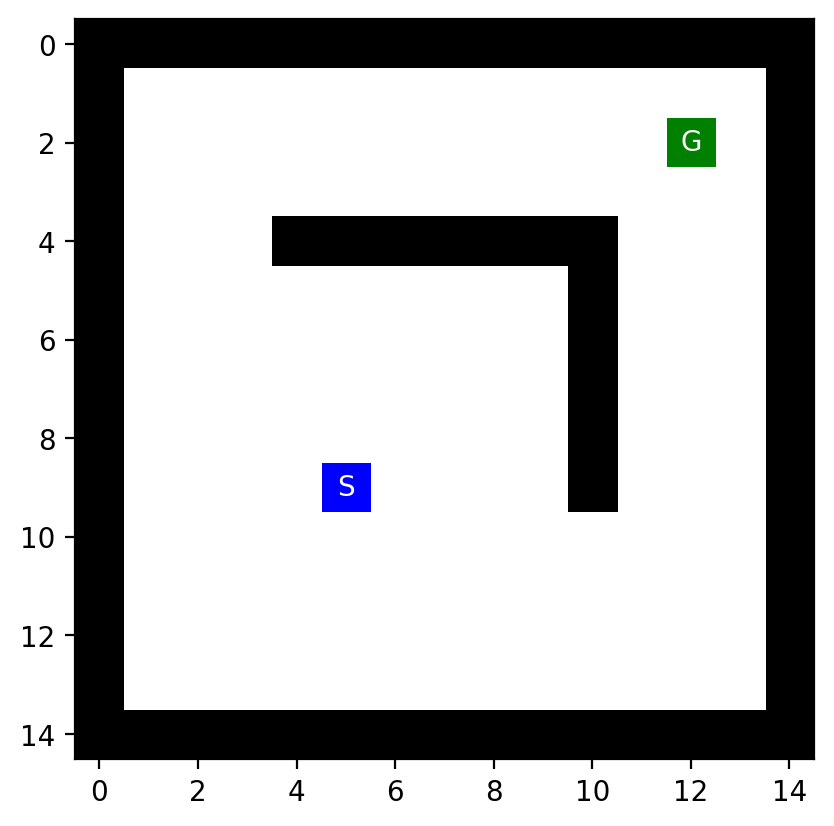

Path: [(np.int64(9), np.int64(5)), (np.int64(9), np.int64(4)), (np.int64(9), np.int64(3)), (np.int64(9), np.int64(2)), (np.int64(9), np.int64(1)), (np.int64(10), np.int64(1)), (np.int64(11), np.int64(1)), (np.int64(12), np.int64(1)), (np.int64(13), np.int64(1)), (np.int64(13), np.int64(2)), (np.int64(13), np.int64(3)), (np.int64(13), np.int64(4)), (np.int64(13), np.int64(5)), (np.int64(13), np.int64(6)), (np.int64(13), np.int64(7)), (np.int64(13), np.int64(8)), (np.int64(13), np.int64(9)), (np.int64(13), np.int64(10)), (np.int64(13), np.int64(11)), (np.int64(13), np.int64(12)), (np.int64(13), np.int64(13)), (np.int64(12), np.int64(13)), (np.int64(12), np.int64(12)), (np.int64(12), np.int64(11)), (np.int64(12), np.int64(10)), (np.int64(12), np.int64(9)), (np.int64(12), np.int64(8)), (np.int64(12), np.int64(7)), (np.int64(12), np.int64(6)), (np.int64(12), np.int64(5)), (np.int64(12), np.int64(4)), (np.int64(12), np.int64(3)), (np.int64(12), np.int64(2)), (np.int64(11), np.int64(2)), (np.

In [7]:
# Note: DFS uses LIFO so the directions come from the stack in reverse order!

# Can get stuck for empty maze since cycle checking is not string enough! 
# I use a maximum number of tries and stop if the goal is not reached.
ts.set_order("NESW")
#ts.set_order("SENW")
#ts.set_order("WSEN")
#ts.set_order(random=True)

%time result = ts.DFS(maze, vis = False, max_tries = 100000, debug_reached = True)

#result
ts.show_path(maze, result)
if result['path'] is None:
    print("No solution found!")

Do the same, but change the order in which we explore states (add them to them as nodes to the frontier).

Directions are checked in the order ['S', 'E', 'N', 'W']
CPU times: total: 0 ns
Wall time: 676 μs
Path length: 26
Reached squares: 27


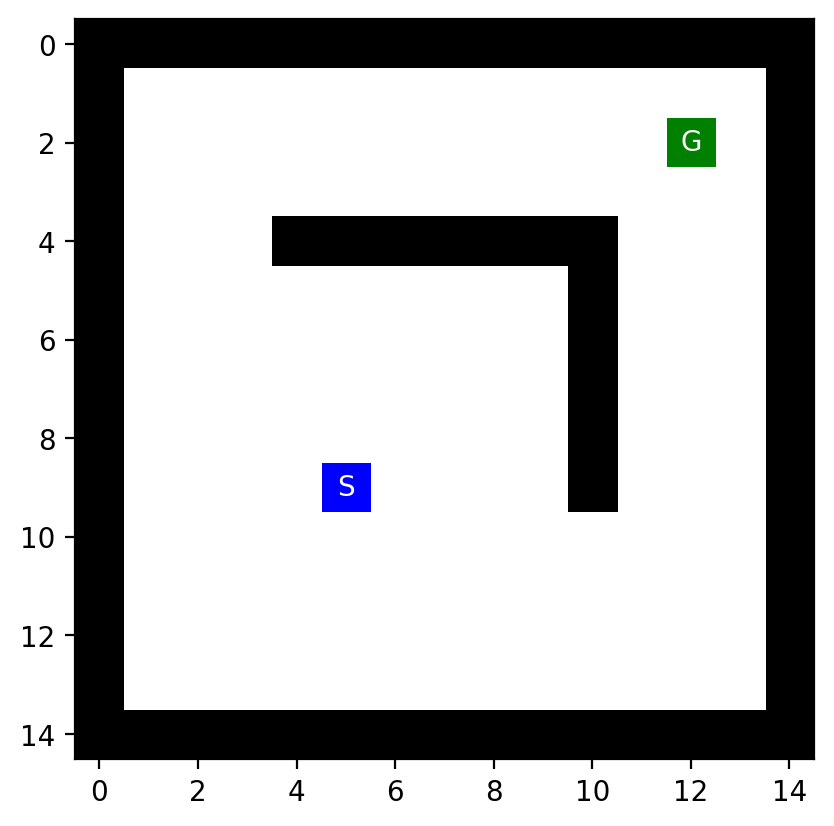

Path: [(np.int64(9), np.int64(5)), (np.int64(9), np.int64(4)), (np.int64(9), np.int64(3)), (np.int64(9), np.int64(2)), (np.int64(9), np.int64(1)), (np.int64(8), np.int64(1)), (np.int64(7), np.int64(1)), (np.int64(6), np.int64(1)), (np.int64(5), np.int64(1)), (np.int64(4), np.int64(1)), (np.int64(3), np.int64(1)), (np.int64(2), np.int64(1)), (np.int64(1), np.int64(1)), (np.int64(1), np.int64(2)), (np.int64(1), np.int64(3)), (np.int64(1), np.int64(4)), (np.int64(1), np.int64(5)), (np.int64(1), np.int64(6)), (np.int64(1), np.int64(7)), (np.int64(1), np.int64(8)), (np.int64(1), np.int64(9)), (np.int64(1), np.int64(10)), (np.int64(1), np.int64(11)), (np.int64(1), np.int64(12)), (np.int64(1), np.int64(13)), (np.int64(2), np.int64(13)), (np.int64(2), np.int64(12))]
Actions: ['W', 'W', 'W', 'W', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'S', 'W']


In [8]:
#ts.set_order("NESW")
ts.set_order("SENW")
#ts.set_order("WSEN")
#ts.set_order(random=True)

%time result = ts.DFS(maze, vis = False, max_tries = 100000, debug_reached = True)

#result
ts.show_path(maze, result)
if result['path'] is None:
    print("No solution found!")

We could do a random walk and not check for cycles. This is guaranteed to reach eventually any square including the goal, 
but creates a long path. The path could be simplified leading to the [Tremaux's algorithm](https://en.wikipedia.org/wiki/Maze_solving_algorithm).

Directions are checked at every step in random order.
CPU times: total: 31.2 ms
Wall time: 26.5 ms
Path length: 632
Reached squares: 123


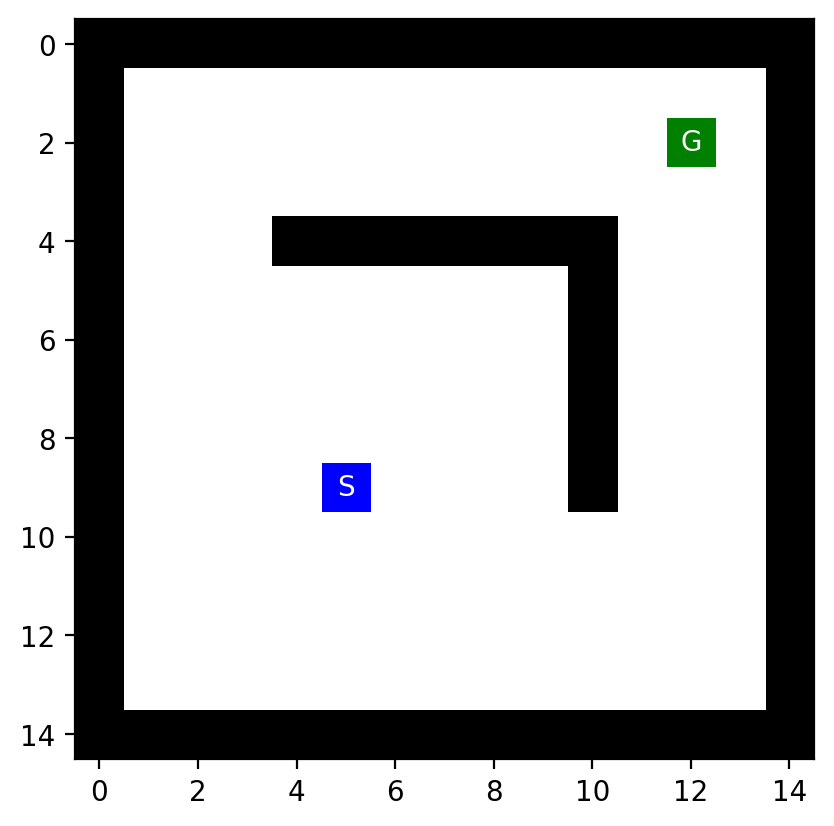

Path: [(np.int64(9), np.int64(5)), (np.int64(8), np.int64(5)), (np.int64(8), np.int64(4)), (np.int64(9), np.int64(4)), (np.int64(10), np.int64(4)), (np.int64(11), np.int64(4)), (np.int64(12), np.int64(4)), (np.int64(13), np.int64(4)), (np.int64(13), np.int64(3)), (np.int64(12), np.int64(3)), (np.int64(13), np.int64(3)), (np.int64(12), np.int64(3)), (np.int64(11), np.int64(3)), (np.int64(10), np.int64(3)), (np.int64(9), np.int64(3)), (np.int64(9), np.int64(4)), (np.int64(8), np.int64(4)), (np.int64(7), np.int64(4)), (np.int64(8), np.int64(4)), (np.int64(8), np.int64(5)), (np.int64(9), np.int64(5)), (np.int64(9), np.int64(4)), (np.int64(8), np.int64(4)), (np.int64(7), np.int64(4)), (np.int64(7), np.int64(3)), (np.int64(6), np.int64(3)), (np.int64(7), np.int64(3)), (np.int64(6), np.int64(3)), (np.int64(6), np.int64(4)), (np.int64(5), np.int64(4)), (np.int64(5), np.int64(3)), (np.int64(5), np.int64(2)), (np.int64(5), np.int64(1)), (np.int64(5), np.int64(2)), (np.int64(4), np.int64(2)), (np

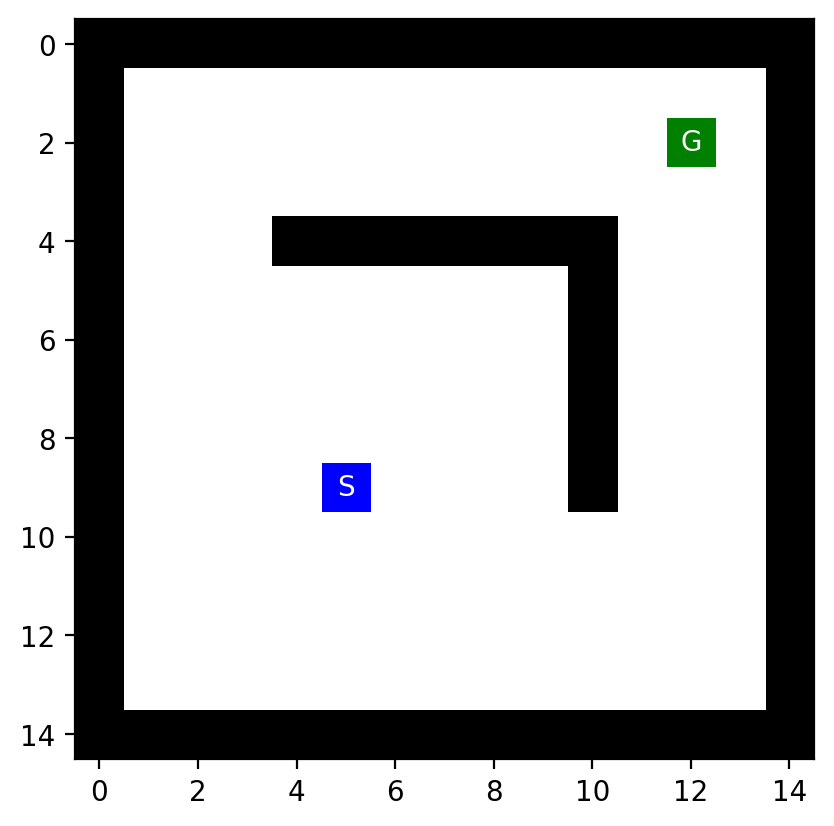

Path: [(np.int64(9), np.int64(5)), (np.int64(8), np.int64(5)), (np.int64(9), np.int64(5)), (np.int64(9), np.int64(4)), (np.int64(10), np.int64(4)), (np.int64(10), np.int64(5)), (np.int64(11), np.int64(5)), (np.int64(11), np.int64(6)), (np.int64(12), np.int64(6)), (np.int64(11), np.int64(6)), (np.int64(11), np.int64(5)), (np.int64(11), np.int64(4)), (np.int64(11), np.int64(3)), (np.int64(10), np.int64(3)), (np.int64(10), np.int64(2)), (np.int64(9), np.int64(2)), (np.int64(9), np.int64(1)), (np.int64(8), np.int64(1)), (np.int64(7), np.int64(1)), (np.int64(7), np.int64(2)), (np.int64(7), np.int64(3)), (np.int64(8), np.int64(3)), (np.int64(8), np.int64(4)), (np.int64(9), np.int64(4)), (np.int64(9), np.int64(3)), (np.int64(9), np.int64(4)), (np.int64(9), np.int64(5)), (np.int64(9), np.int64(6)), (np.int64(8), np.int64(6)), (np.int64(8), np.int64(7)), (np.int64(8), np.int64(8)), (np.int64(7), np.int64(8)), (np.int64(8), np.int64(8)), (np.int64(8), np.int64(7)), (np.int64(8), np.int64(8)), (n

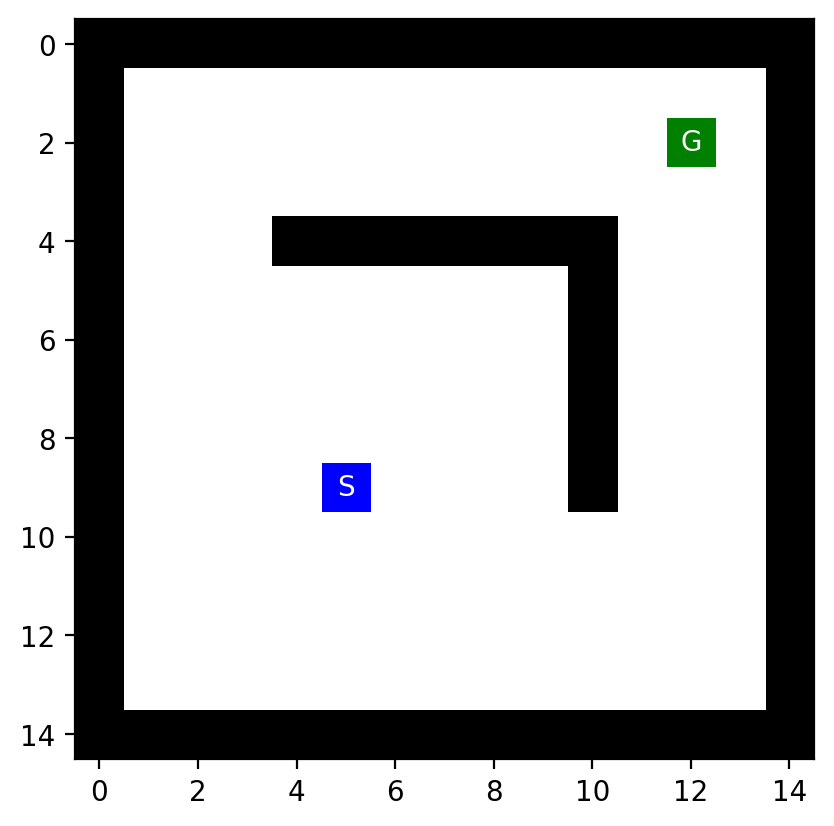

Path: [(np.int64(9), np.int64(5)), (np.int64(10), np.int64(5)), (np.int64(10), np.int64(6)), (np.int64(10), np.int64(5)), (np.int64(10), np.int64(6)), (np.int64(11), np.int64(6)), (np.int64(10), np.int64(6)), (np.int64(11), np.int64(6)), (np.int64(11), np.int64(5)), (np.int64(12), np.int64(5)), (np.int64(13), np.int64(5)), (np.int64(13), np.int64(4)), (np.int64(12), np.int64(4)), (np.int64(12), np.int64(5)), (np.int64(13), np.int64(5)), (np.int64(12), np.int64(5)), (np.int64(12), np.int64(4)), (np.int64(12), np.int64(5)), (np.int64(12), np.int64(6)), (np.int64(12), np.int64(5)), (np.int64(12), np.int64(6)), (np.int64(12), np.int64(7)), (np.int64(12), np.int64(8)), (np.int64(11), np.int64(8)), (np.int64(12), np.int64(8)), (np.int64(13), np.int64(8)), (np.int64(13), np.int64(9)), (np.int64(13), np.int64(10)), (np.int64(13), np.int64(11)), (np.int64(12), np.int64(11)), (np.int64(12), np.int64(10)), (np.int64(12), np.int64(11)), (np.int64(12), np.int64(12)), (np.int64(12), np.int64(11)), (

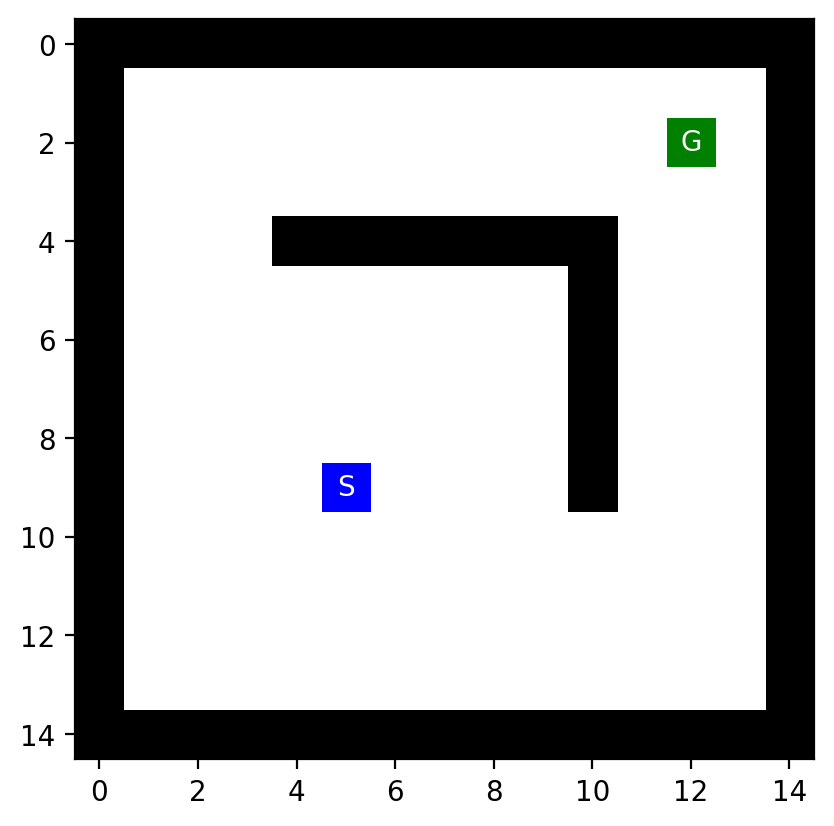

Path: [(np.int64(9), np.int64(5)), (np.int64(9), np.int64(6)), (np.int64(10), np.int64(6)), (np.int64(9), np.int64(6)), (np.int64(9), np.int64(5)), (np.int64(10), np.int64(5)), (np.int64(10), np.int64(4)), (np.int64(11), np.int64(4)), (np.int64(10), np.int64(4)), (np.int64(10), np.int64(5)), (np.int64(10), np.int64(6)), (np.int64(10), np.int64(5)), (np.int64(10), np.int64(6)), (np.int64(9), np.int64(6)), (np.int64(9), np.int64(5)), (np.int64(10), np.int64(5)), (np.int64(10), np.int64(6)), (np.int64(10), np.int64(7)), (np.int64(10), np.int64(6)), (np.int64(9), np.int64(6)), (np.int64(8), np.int64(6)), (np.int64(7), np.int64(6)), (np.int64(8), np.int64(6)), (np.int64(9), np.int64(6)), (np.int64(9), np.int64(7)), (np.int64(10), np.int64(7)), (np.int64(10), np.int64(6)), (np.int64(11), np.int64(6)), (np.int64(10), np.int64(6)), (np.int64(9), np.int64(6)), (np.int64(8), np.int64(6)), (np.int64(9), np.int64(6)), (np.int64(9), np.int64(7)), (np.int64(8), np.int64(7)), (np.int64(8), np.int64(6

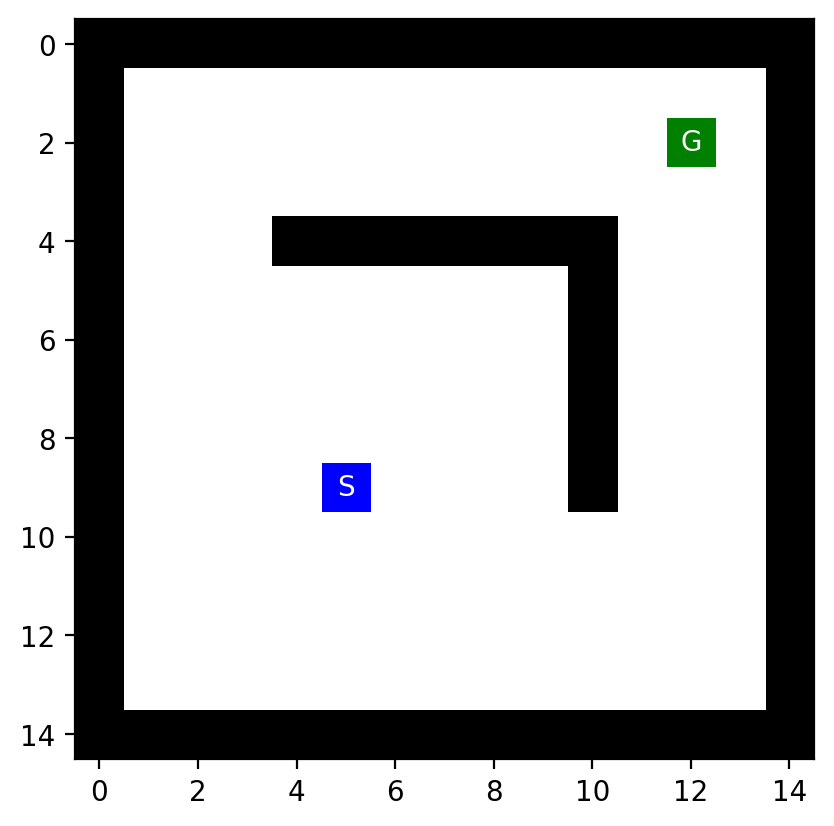

Path: [(np.int64(9), np.int64(5)), (np.int64(9), np.int64(4)), (np.int64(9), np.int64(3)), (np.int64(8), np.int64(3)), (np.int64(8), np.int64(4)), (np.int64(8), np.int64(5)), (np.int64(8), np.int64(4)), (np.int64(7), np.int64(4)), (np.int64(6), np.int64(4)), (np.int64(7), np.int64(4)), (np.int64(7), np.int64(5)), (np.int64(6), np.int64(5)), (np.int64(6), np.int64(6)), (np.int64(5), np.int64(6)), (np.int64(5), np.int64(7)), (np.int64(5), np.int64(8)), (np.int64(6), np.int64(8)), (np.int64(7), np.int64(8)), (np.int64(6), np.int64(8)), (np.int64(6), np.int64(9)), (np.int64(7), np.int64(9)), (np.int64(8), np.int64(9)), (np.int64(7), np.int64(9)), (np.int64(8), np.int64(9)), (np.int64(9), np.int64(9)), (np.int64(10), np.int64(9)), (np.int64(11), np.int64(9)), (np.int64(11), np.int64(10)), (np.int64(11), np.int64(11)), (np.int64(11), np.int64(10)), (np.int64(11), np.int64(9)), (np.int64(11), np.int64(10)), (np.int64(11), np.int64(11)), (np.int64(11), np.int64(10)), (np.int64(11), np.int64(11

In [9]:
ts.set_order(random = True)

# run it multiple times to see the effect of randomization
for _ in range(5):
    %time result = ts.DFS(maze, check_cycle = False, max_tries = 100000, vis = False, debug_reached = True)

    #result
    ts.show_path(maze, result)
    if result['path'] is None:
        print("No solution found!")

### Run randomized DFS multiple times and use the best solution.

__Note:__ IDS takes a similar amount of time and memory, but is guaranteed optimal.

Directions are checked at every step in random order.
CPU times: total: 3.48 s
Wall time: 3.62 s
Solutions have path_lengths of [54, 52, 68, 72, 88, 62, 42, 48, 72, 70, 70, 74, 54, 54, 48, 60, 60, 46, 92, 38, 74, 58, 56, 68, 52, 76, 90, 52, 66, 50, 76, 66, 82, 54, 38, 58, 28, 72, 78, 58, 76, 56, 60, 62, 100, 40, 40, 80, 76, 78, 68, 66, 56, 46, 76, 46, 52, 46, 70, 64, 52, 42, 34, 42, 44, 82, 76, 54, 80, 60, 72, 62, 82, 54, 54, 58, 66]
Path length: 28
Reached squares: 29


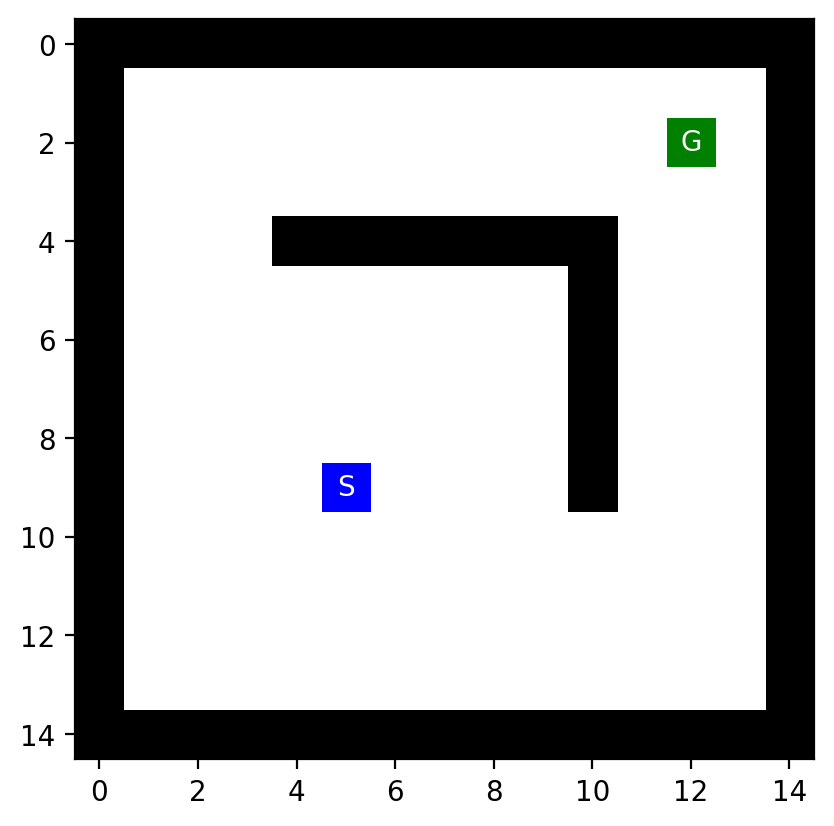

Path: [(np.int64(9), np.int64(5)), (np.int64(8), np.int64(5)), (np.int64(8), np.int64(4)), (np.int64(9), np.int64(4)), (np.int64(9), np.int64(3)), (np.int64(8), np.int64(3)), (np.int64(7), np.int64(3)), (np.int64(6), np.int64(3)), (np.int64(6), np.int64(4)), (np.int64(5), np.int64(4)), (np.int64(5), np.int64(3)), (np.int64(5), np.int64(2)), (np.int64(4), np.int64(2)), (np.int64(4), np.int64(1)), (np.int64(3), np.int64(1)), (np.int64(3), np.int64(2)), (np.int64(2), np.int64(2)), (np.int64(1), np.int64(2)), (np.int64(1), np.int64(3)), (np.int64(1), np.int64(4)), (np.int64(1), np.int64(5)), (np.int64(1), np.int64(6)), (np.int64(1), np.int64(7)), (np.int64(1), np.int64(8)), (np.int64(1), np.int64(9)), (np.int64(1), np.int64(10)), (np.int64(1), np.int64(11)), (np.int64(1), np.int64(12)), (np.int64(2), np.int64(12))]
Actions: ['N', 'W', 'S', 'W', 'N', 'N', 'N', 'E', 'N', 'W', 'W', 'N', 'W', 'N', 'E', 'N', 'N', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'E', 'S']


In [10]:
ts.set_order(random = True)

N = 100
%time results = [ ts.DFS(maze, max_tries = 10000, vis = False) for _ in range(N) ]

# check if we found a solution and display the best solution
results = [ r for r in results if not r['path'] is None ]
if len(results) > 0:
    path_lengths = [ len(r['path'])-1 for r in results ]

    print(f"Solutions have path_lengths of {path_lengths}")

    result = results[ts.min_index(path_lengths)]
    ts.show_path(maze, result)
else:
    print("No solution found!")

### Depth limited DFS

Note: The frontier needs to be checked differently during cycle checking!

Directions are checked at every step in random order.
CPU times: total: 15.6 ms
Wall time: 2.02 ms
Path length: No solution found
Reached squares: 57


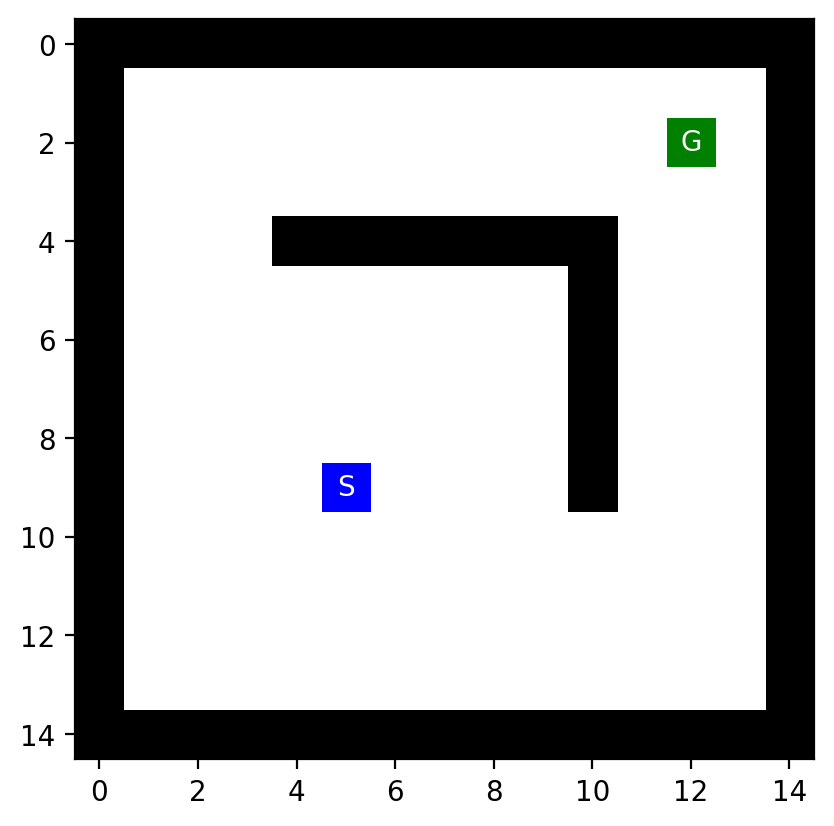

In [11]:
ts.set_order(random = True)

%time result = ts.DFS(maze, limit = 5, frontier_option = 2, max_tries = 100000, vis = False, debug_reached = True)
ts.show_path(maze, result)

### BÀI 4 - KHẢO SÁT DLS

In [12]:
with open("L_maze.txt", "r") as f:
    maze = parse_maze(f.read())

ts.set_order("NESW")

limits = [5, 10, 15, 16, 20, 30]

for depth_limit in limits:
    result = ts.DFS(
        maze,
        limit=depth_limit,
        frontier_option=2,
        max_tries=100000,
        vis=False,
        debug_reached=True
    )

    actions = result["actions"]

    print(f"\n===== LIMIT = {depth_limit} =====")
    print("Tìm được lời giải:", actions is not None)
    print(
        "Path length:",
        len(actions) if actions is not None else "N/A"
    )
    print("Expanded count:", result.get("expanded_count"))
    print("Max frontier:", result.get("max_frontier"))

Directions are checked in the order ['N', 'E', 'S', 'W']

===== LIMIT = 5 =====
Tìm được lời giải: False
Path length: N/A
Expanded count: 153
Max frontier: 11

===== LIMIT = 10 =====
Tìm được lời giải: False
Path length: N/A
Expanded count: 17687
Max frontier: 18

===== LIMIT = 15 =====
Tìm được lời giải: False
Path length: N/A
Expanded count: 43765
Max frontier: 24

===== LIMIT = 16 =====
Tìm được lời giải: False
Path length: N/A
Expanded count: 44537
Max frontier: 26

===== LIMIT = 20 =====
Tìm được lời giải: False
Path length: N/A
Expanded count: 42535
Max frontier: 27

===== LIMIT = 30 =====
Tìm được lời giải: True
Path length: 30
Expanded count: 4573
Max frontier: 42


### IDS

__Notes:__ 

* IDS with DFS does not store reached squares, so gray areas are not shown!

* IDS depends on the cycle checking of DFS and therefore is also affected by these problems.

Directions are checked at every step in random order.
IDS đang thử giới hạn độ sâu: 0
IDS đang thử giới hạn độ sâu: 1
IDS đang thử giới hạn độ sâu: 2
IDS đang thử giới hạn độ sâu: 3
IDS đang thử giới hạn độ sâu: 4
IDS đang thử giới hạn độ sâu: 5
IDS đang thử giới hạn độ sâu: 6
IDS đang thử giới hạn độ sâu: 7
IDS đang thử giới hạn độ sâu: 8
IDS đang thử giới hạn độ sâu: 9
IDS đang thử giới hạn độ sâu: 10
IDS đang thử giới hạn độ sâu: 11
IDS đang thử giới hạn độ sâu: 12
IDS đang thử giới hạn độ sâu: 13
IDS đang thử giới hạn độ sâu: 14
IDS đang thử giới hạn độ sâu: 15
IDS đang thử giới hạn độ sâu: 16
IDS đang thử giới hạn độ sâu: 17
IDS đang thử giới hạn độ sâu: 18
IDS đang thử giới hạn độ sâu: 19
CPU times: total: 3.48 s
Wall time: 3.61 s
Path length: 18
Reached squares: 85


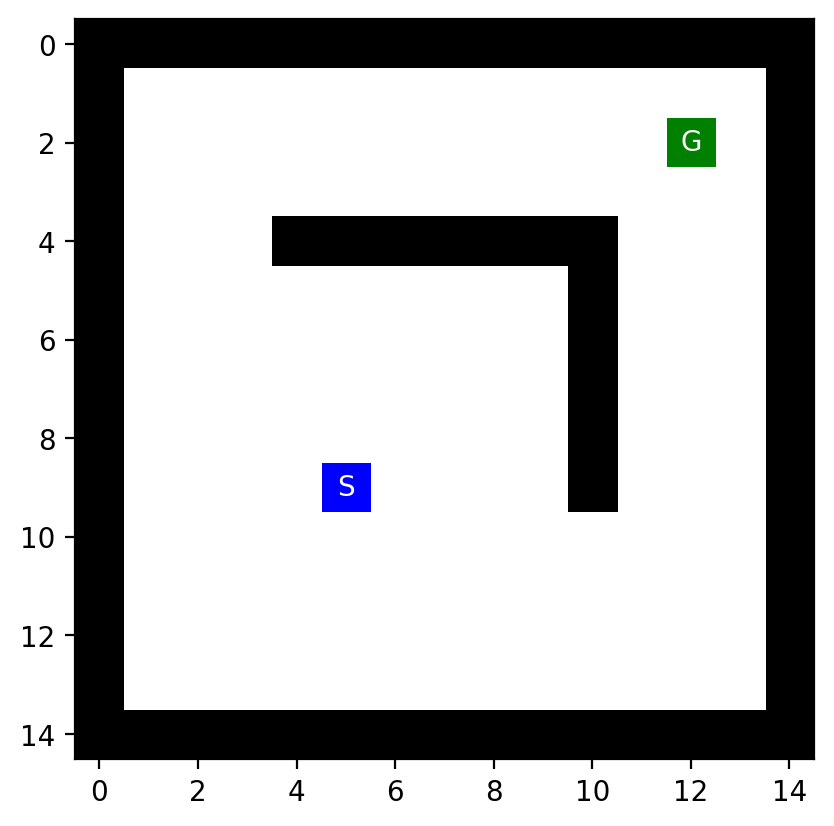

Path: [(np.int64(9), np.int64(5)), (np.int64(10), np.int64(5)), (np.int64(10), np.int64(6)), (np.int64(10), np.int64(7)), (np.int64(10), np.int64(8)), (np.int64(10), np.int64(9)), (np.int64(11), np.int64(9)), (np.int64(11), np.int64(10)), (np.int64(10), np.int64(10)), (np.int64(10), np.int64(11)), (np.int64(10), np.int64(12)), (np.int64(9), np.int64(12)), (np.int64(8), np.int64(12)), (np.int64(7), np.int64(12)), (np.int64(6), np.int64(12)), (np.int64(5), np.int64(12)), (np.int64(4), np.int64(12)), (np.int64(3), np.int64(12)), (np.int64(2), np.int64(12))]
Actions: ['S', 'E', 'E', 'E', 'E', 'S', 'E', 'N', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [13]:
ts.set_order(random = True)

%time result = ts.IDS(maze, frontier_option = 2, max_tries = 100000)
ts.show_path(maze, result)

### BÀI 4 - KHẢO SÁT IDS

In [14]:
with open("small_maze.txt", "r") as f:
    maze_ids = parse_maze(f.read())

ts.set_order("NESW")

result_ids = ts.IDS(
    maze_ids,
    frontier_option=2,
    max_tries=100000,
    vis=False
)

print("Tìm được lời giải:", result_ids["path"] is not None)

if result_ids["actions"] is not None:
    print("Path length:", len(result_ids["actions"]))
else:
    print("Path length: N/A")

Directions are checked in the order ['N', 'E', 'S', 'W']
IDS đang thử giới hạn độ sâu: 0
IDS đang thử giới hạn độ sâu: 1
IDS đang thử giới hạn độ sâu: 2
IDS đang thử giới hạn độ sâu: 3
IDS đang thử giới hạn độ sâu: 4
IDS đang thử giới hạn độ sâu: 5
IDS đang thử giới hạn độ sâu: 6
IDS đang thử giới hạn độ sâu: 7
IDS đang thử giới hạn độ sâu: 8
IDS đang thử giới hạn độ sâu: 9
IDS đang thử giới hạn độ sâu: 10
IDS đang thử giới hạn độ sâu: 11
IDS đang thử giới hạn độ sâu: 12
IDS đang thử giới hạn độ sâu: 13
IDS đang thử giới hạn độ sâu: 14
IDS đang thử giới hạn độ sâu: 15
IDS đang thử giới hạn độ sâu: 16
IDS đang thử giới hạn độ sâu: 17
IDS đang thử giới hạn độ sâu: 18
IDS đang thử giới hạn độ sâu: 19
Tìm được lời giải: True
Path length: 19


Path length: 19
Reached squares: 50


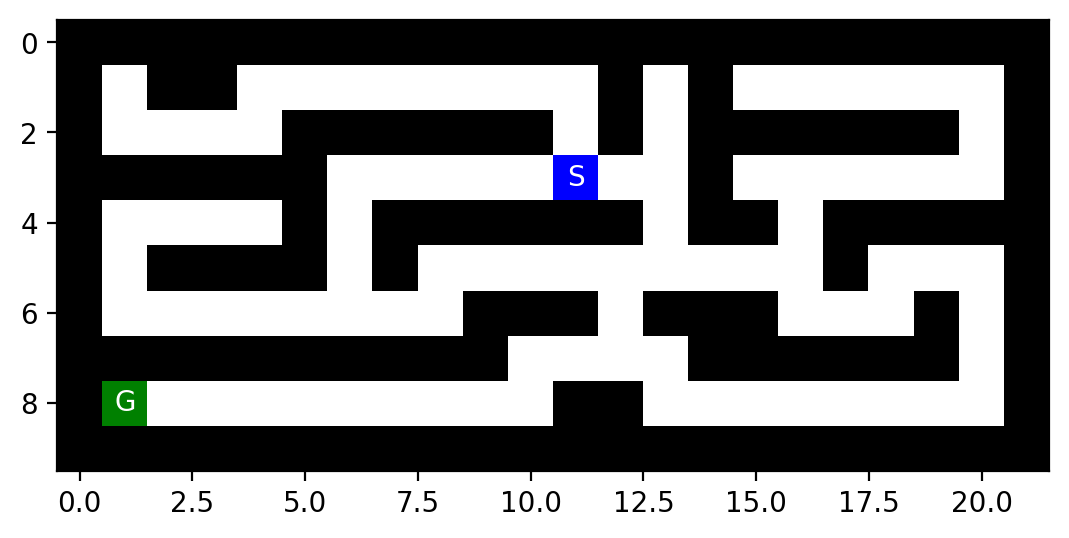

Path: [(np.int64(3), np.int64(11)), (np.int64(3), np.int64(12)), (np.int64(3), np.int64(13)), (np.int64(4), np.int64(13)), (np.int64(5), np.int64(13)), (np.int64(5), np.int64(12)), (np.int64(6), np.int64(12)), (np.int64(7), np.int64(12)), (np.int64(7), np.int64(11)), (np.int64(7), np.int64(10)), (np.int64(8), np.int64(10)), (np.int64(8), np.int64(9)), (np.int64(8), np.int64(8)), (np.int64(8), np.int64(7)), (np.int64(8), np.int64(6)), (np.int64(8), np.int64(5)), (np.int64(8), np.int64(4)), (np.int64(8), np.int64(3)), (np.int64(8), np.int64(2)), (np.int64(8), np.int64(1))]
Actions: ['E', 'E', 'S', 'S', 'W', 'S', 'S', 'W', 'W', 'S', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W', 'W']


In [27]:
ts.show_path(maze_ids, result_ids)

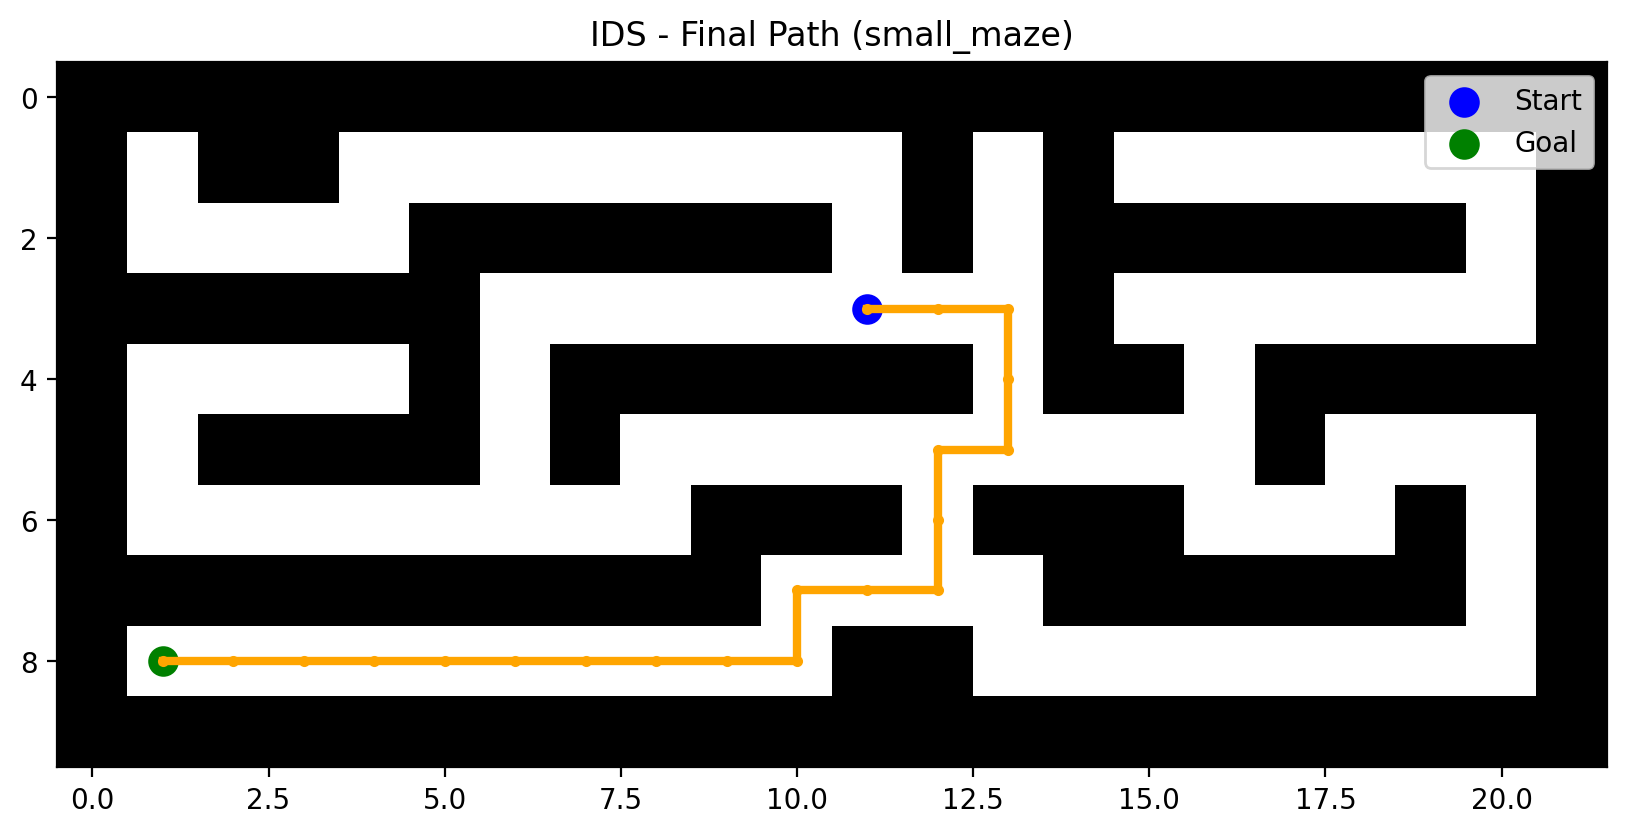

In [28]:
import numpy as np
import matplotlib.pyplot as plt

maze_array = np.asarray(maze_ids)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(maze_array == "X", cmap="gray_r")

path = result_ids["path"]

if path is not None:
    rows = [int(pos[0]) for pos in path]
    cols = [int(pos[1]) for pos in path]

    ax.plot(cols, rows, color="orange", linewidth=3,
            marker="o", markersize=3)

    ax.scatter(cols[0], rows[0], color="blue", s=100, label="Start")
    ax.scatter(cols[-1], rows[-1], color="green", s=100, label="Goal")

ax.set_title("IDS - Final Path (small_maze)")
ax.legend()
plt.show()

### Greedy Best-First Search (GBFS)

In [15]:
# set the heuristic to Manhattan distance
ts.heuristic = ts.manhattan

Directions are checked at every step in random order.
CPU times: total: 0 ns
Wall time: 656 μs
Path length: 22
Reached squares: 33


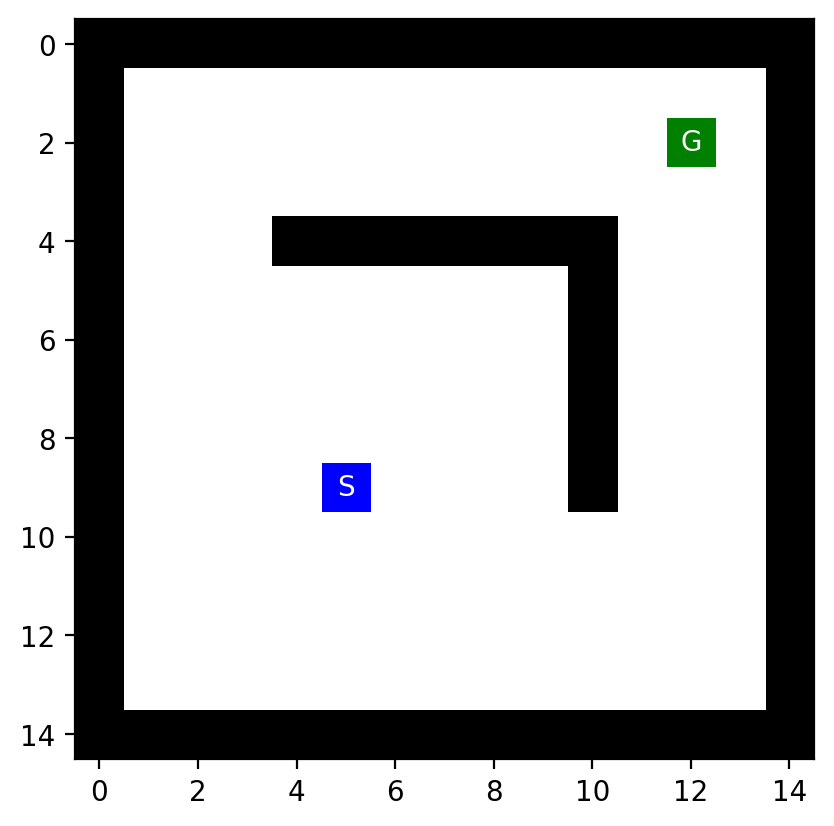

Path: [(np.int64(9), np.int64(5)), (np.int64(8), np.int64(5)), (np.int64(8), np.int64(6)), (np.int64(7), np.int64(6)), (np.int64(7), np.int64(7)), (np.int64(6), np.int64(7)), (np.int64(6), np.int64(8)), (np.int64(6), np.int64(9)), (np.int64(7), np.int64(9)), (np.int64(8), np.int64(9)), (np.int64(9), np.int64(9)), (np.int64(10), np.int64(9)), (np.int64(10), np.int64(10)), (np.int64(10), np.int64(11)), (np.int64(9), np.int64(11)), (np.int64(8), np.int64(11)), (np.int64(7), np.int64(11)), (np.int64(7), np.int64(12)), (np.int64(6), np.int64(12)), (np.int64(5), np.int64(12)), (np.int64(4), np.int64(12)), (np.int64(3), np.int64(12)), (np.int64(2), np.int64(12))]
Actions: ['N', 'E', 'N', 'E', 'N', 'E', 'E', 'S', 'S', 'S', 'S', 'E', 'E', 'N', 'N', 'N', 'E', 'N', 'N', 'N', 'N', 'N']


In [16]:
ts.set_order(random=True)

%time result = ts.best_first_search(maze, strategy = "GBFS", debug = False, vis = False)
ts.show_path(maze, result)

### A* Search

Directions are checked at every step in random order.
CPU times: total: 0 ns
Wall time: 970 μs
Path length: 16
Reached squares: 37


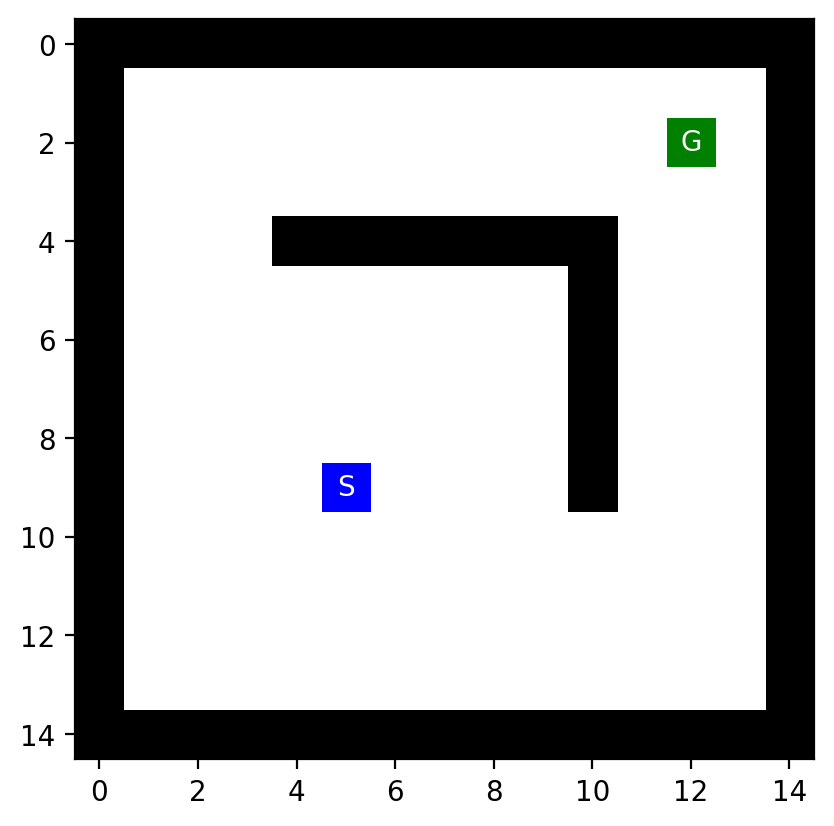

Path: [(np.int64(9), np.int64(5)), (np.int64(9), np.int64(6)), (np.int64(9), np.int64(7)), (np.int64(9), np.int64(8)), (np.int64(9), np.int64(9)), (np.int64(10), np.int64(9)), (np.int64(10), np.int64(10)), (np.int64(10), np.int64(11)), (np.int64(10), np.int64(12)), (np.int64(9), np.int64(12)), (np.int64(8), np.int64(12)), (np.int64(7), np.int64(12)), (np.int64(6), np.int64(12)), (np.int64(5), np.int64(12)), (np.int64(4), np.int64(12)), (np.int64(3), np.int64(12)), (np.int64(2), np.int64(12))]
Actions: ['E', 'E', 'E', 'E', 'S', 'E', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [17]:
ts.set_order(random=True)

%time result = ts.best_first_search(maze, strategy = "A*", debug = False, vis = False)
ts.show_path(maze, result)

### Weighted A* Search

$W > 1$ tends towards GBFS (optimality is not guaranteed)

Directions are checked at every step in random order.
CPU times: total: 0 ns
Wall time: 839 μs
Path length: 16
Reached squares: 38


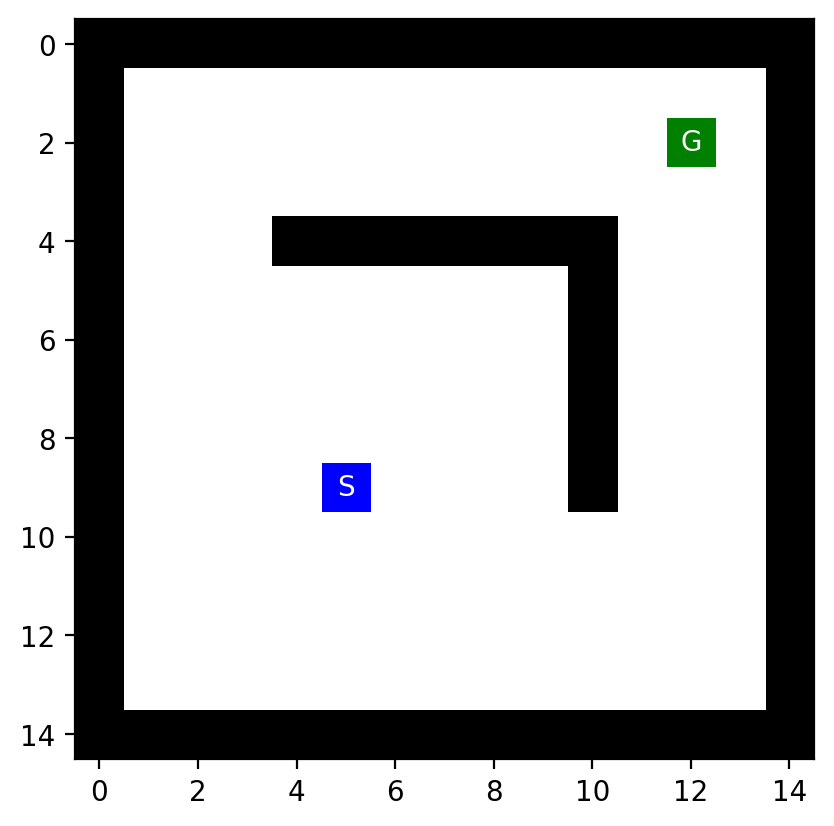

Path: [(np.int64(9), np.int64(5)), (np.int64(9), np.int64(6)), (np.int64(9), np.int64(7)), (np.int64(9), np.int64(8)), (np.int64(9), np.int64(9)), (np.int64(10), np.int64(9)), (np.int64(10), np.int64(10)), (np.int64(10), np.int64(11)), (np.int64(10), np.int64(12)), (np.int64(9), np.int64(12)), (np.int64(8), np.int64(12)), (np.int64(7), np.int64(12)), (np.int64(6), np.int64(12)), (np.int64(5), np.int64(12)), (np.int64(4), np.int64(12)), (np.int64(3), np.int64(12)), (np.int64(2), np.int64(12))]
Actions: ['E', 'E', 'E', 'E', 'S', 'E', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [18]:
ts.set_order(random=True)

%time result = ts.best_first_search(maze, strategy = "A*", W = 1+1e-9, debug = False, vis = False)
ts.show_path(maze, result)

CPU times: total: 0 ns
Wall time: 948 μs
Path length: 18
Reached squares: 36


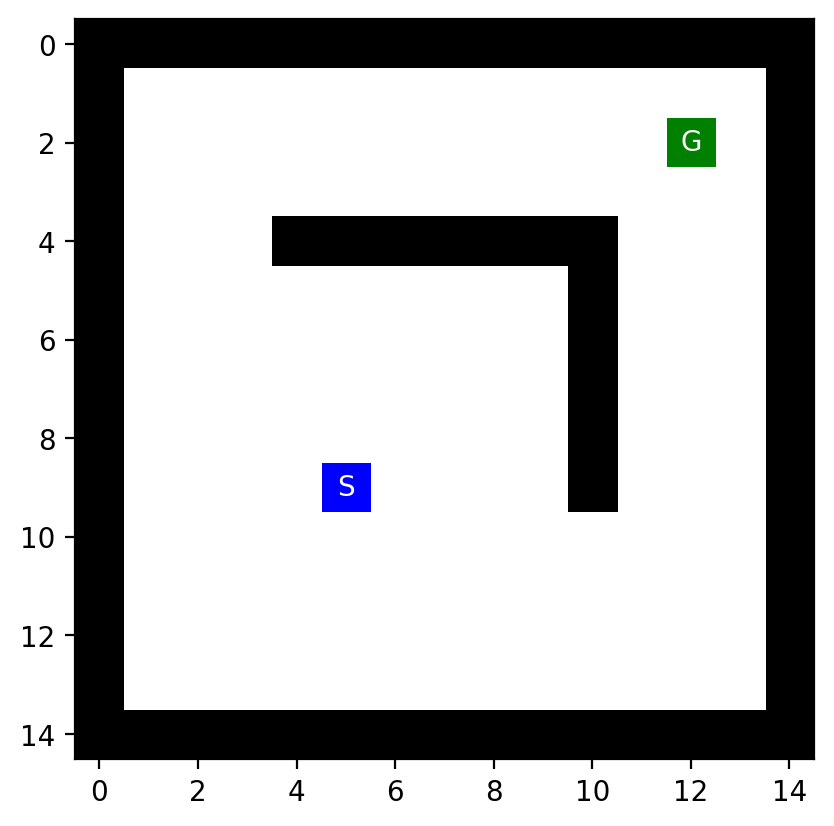

Path: [(np.int64(9), np.int64(5)), (np.int64(8), np.int64(5)), (np.int64(8), np.int64(6)), (np.int64(8), np.int64(7)), (np.int64(8), np.int64(8)), (np.int64(8), np.int64(9)), (np.int64(9), np.int64(9)), (np.int64(10), np.int64(9)), (np.int64(10), np.int64(10)), (np.int64(10), np.int64(11)), (np.int64(10), np.int64(12)), (np.int64(9), np.int64(12)), (np.int64(8), np.int64(12)), (np.int64(7), np.int64(12)), (np.int64(6), np.int64(12)), (np.int64(5), np.int64(12)), (np.int64(4), np.int64(12)), (np.int64(3), np.int64(12)), (np.int64(2), np.int64(12))]
Actions: ['N', 'E', 'E', 'E', 'E', 'S', 'S', 'E', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [19]:
%time result = ts.best_first_search(maze, strategy = "A*", W = 5, debug = False, vis = False)
ts.show_path(maze, result)

CPU times: total: 0 ns
Wall time: 774 μs
Path length: 20
Reached squares: 35


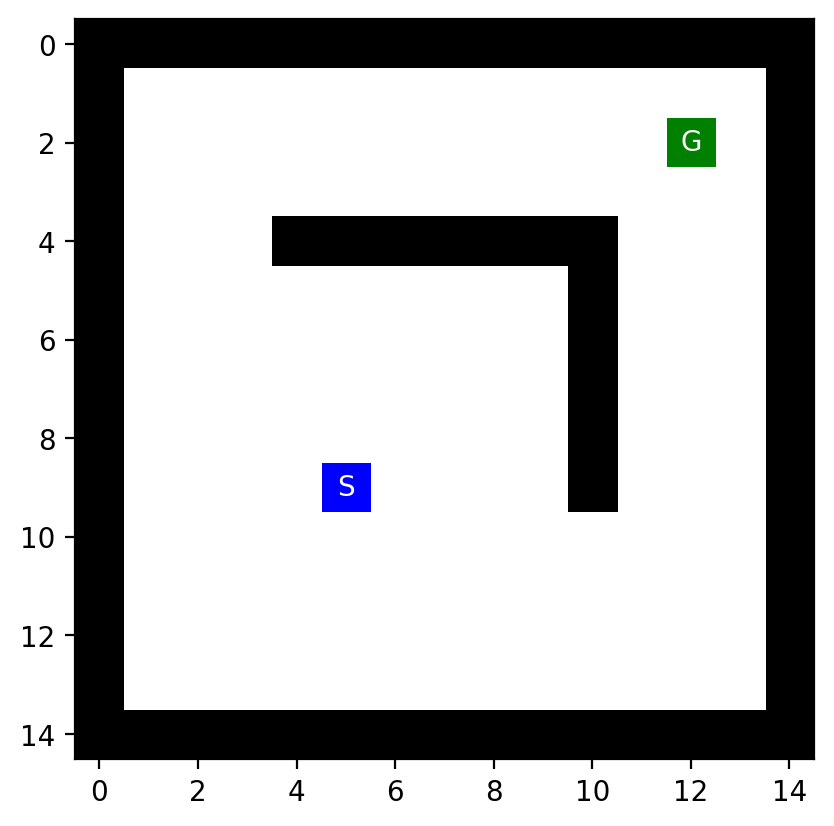

Path: [(np.int64(9), np.int64(5)), (np.int64(8), np.int64(5)), (np.int64(7), np.int64(5)), (np.int64(7), np.int64(6)), (np.int64(7), np.int64(7)), (np.int64(7), np.int64(8)), (np.int64(7), np.int64(9)), (np.int64(8), np.int64(9)), (np.int64(9), np.int64(9)), (np.int64(10), np.int64(9)), (np.int64(10), np.int64(10)), (np.int64(10), np.int64(11)), (np.int64(10), np.int64(12)), (np.int64(9), np.int64(12)), (np.int64(8), np.int64(12)), (np.int64(7), np.int64(12)), (np.int64(6), np.int64(12)), (np.int64(5), np.int64(12)), (np.int64(4), np.int64(12)), (np.int64(3), np.int64(12)), (np.int64(2), np.int64(12))]
Actions: ['N', 'N', 'E', 'E', 'E', 'E', 'S', 'S', 'S', 'E', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [20]:
%time result = ts.best_first_search(maze, strategy = "A*", W = 1000, debug = False, vis = False)
ts.show_path(maze, result)

$W<1$ tends towards Uniform-Cost Search/BFS (optimality is guaranteed)

CPU times: total: 0 ns
Wall time: 2.33 ms
Path length: 16
Reached squares: 89


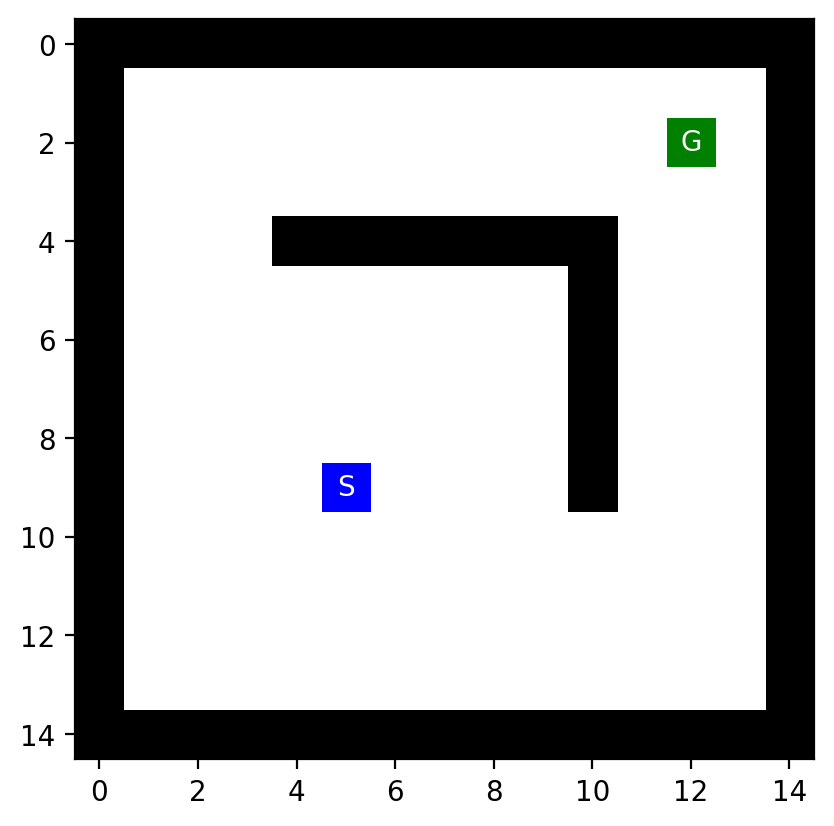

Path: [(np.int64(9), np.int64(5)), (np.int64(9), np.int64(6)), (np.int64(9), np.int64(7)), (np.int64(9), np.int64(8)), (np.int64(9), np.int64(9)), (np.int64(10), np.int64(9)), (np.int64(10), np.int64(10)), (np.int64(10), np.int64(11)), (np.int64(9), np.int64(11)), (np.int64(8), np.int64(11)), (np.int64(7), np.int64(11)), (np.int64(6), np.int64(11)), (np.int64(5), np.int64(11)), (np.int64(4), np.int64(11)), (np.int64(3), np.int64(11)), (np.int64(2), np.int64(11)), (np.int64(2), np.int64(12))]
Actions: ['E', 'E', 'E', 'E', 'S', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'E']


In [21]:
%time result = ts.best_first_search(maze, strategy = "A*", W = .7, debug = False, vis = False)
ts.show_path(maze, result)

CPU times: total: 0 ns
Wall time: 9.47 ms
Path length: 16
Reached squares: 149


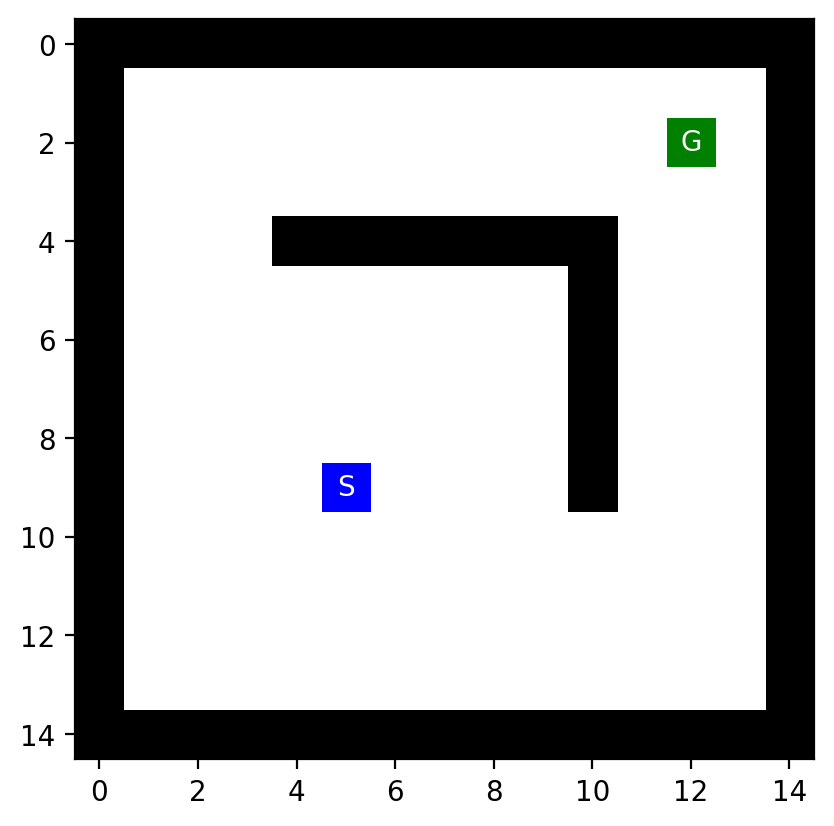

Path: [(np.int64(9), np.int64(5)), (np.int64(9), np.int64(6)), (np.int64(9), np.int64(7)), (np.int64(9), np.int64(8)), (np.int64(9), np.int64(9)), (np.int64(10), np.int64(9)), (np.int64(10), np.int64(10)), (np.int64(10), np.int64(11)), (np.int64(9), np.int64(11)), (np.int64(8), np.int64(11)), (np.int64(7), np.int64(11)), (np.int64(6), np.int64(11)), (np.int64(5), np.int64(11)), (np.int64(4), np.int64(11)), (np.int64(3), np.int64(11)), (np.int64(2), np.int64(11)), (np.int64(2), np.int64(12))]
Actions: ['E', 'E', 'E', 'E', 'S', 'E', 'E', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'E']


In [22]:
%time result = ts.best_first_search(maze, strategy = "A*", W = .0001, debug = False, vis = False)
ts.show_path(maze, result)

### Compare Timing

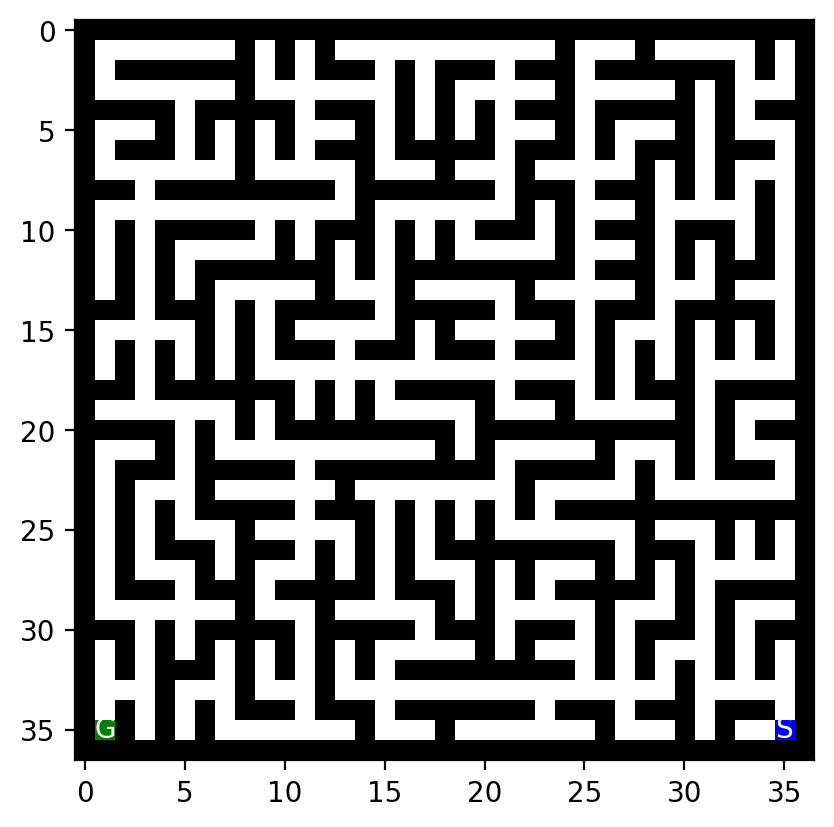

Directions are checked at every step in random order.


In [23]:
#f = open("small_maze.txt", "r")
#f = open("medium_maze.txt", "r")
f = open("large_maze.txt", "r")    # this has only one solution!
#f = open("open_maze.txt", "r")
#f = open("empty_maze.txt", "r")
#f = open("empty_maze_2.txt", "r")
#f = open("L_maze.txt", "r")
#f = open("loops_maze.txt", "r")

maze_str = f.read()
maze = parse_maze(maze_str)

ts.show_maze(maze)

ts.set_order(random=True)


In [24]:
import timeit
import math

reps = 10

times = {}

algorithms = ["BFS", "DFS", "GBFS", "A*"]

### FIXME: add IDS

for a in algorithms:
    times[a] = math.ceil(timeit.timeit(stmt = f'ts.best_first_search(maze, strategy = "{a}", debug = False, vis = False)', 
              setup = 'from __main__ import ts, maze',
                    number = reps)*1e6/reps)
    
times['DFS(no reached)'] = math.ceil(timeit.timeit(stmt = f'ts.DFS(maze, vis = False)', 
              setup = 'from __main__ import ts, maze',
                    number = reps)*1e6/reps)

times['IDS'] = math.ceil(timeit.timeit(stmt = f'ts.IDS(maze, vis = False)', 
              setup = 'from __main__ import ts, maze',
                    number = reps)*1e6/reps)

IDS đang thử giới hạn độ sâu: 0
IDS đang thử giới hạn độ sâu: 1
IDS đang thử giới hạn độ sâu: 2
IDS đang thử giới hạn độ sâu: 3
IDS đang thử giới hạn độ sâu: 4
IDS đang thử giới hạn độ sâu: 5
IDS đang thử giới hạn độ sâu: 6
IDS đang thử giới hạn độ sâu: 7
IDS đang thử giới hạn độ sâu: 8
IDS đang thử giới hạn độ sâu: 9
IDS đang thử giới hạn độ sâu: 10
IDS đang thử giới hạn độ sâu: 11
IDS đang thử giới hạn độ sâu: 12
IDS đang thử giới hạn độ sâu: 13
IDS đang thử giới hạn độ sâu: 14
IDS đang thử giới hạn độ sâu: 15
IDS đang thử giới hạn độ sâu: 16
IDS đang thử giới hạn độ sâu: 17
IDS đang thử giới hạn độ sâu: 18
IDS đang thử giới hạn độ sâu: 19
IDS đang thử giới hạn độ sâu: 20
IDS đang thử giới hạn độ sâu: 21
IDS đang thử giới hạn độ sâu: 22
IDS đang thử giới hạn độ sâu: 23
IDS đang thử giới hạn độ sâu: 24
IDS đang thử giới hạn độ sâu: 25
IDS đang thử giới hạn độ sâu: 26
IDS đang thử giới hạn độ sâu: 27
IDS đang thử giới hạn độ sâu: 28
IDS đang thử giới hạn độ sâu: 29
IDS đang thử giới hạ

In [25]:
import pandas as pd
df = pd.DataFrame(times, index = ["time in micro seconds"])
df

,BFS,DFS,GBFS,A*,DFS(no reached),IDS
time in micro seconds,16779,19417,12490,18774,18784,1421474


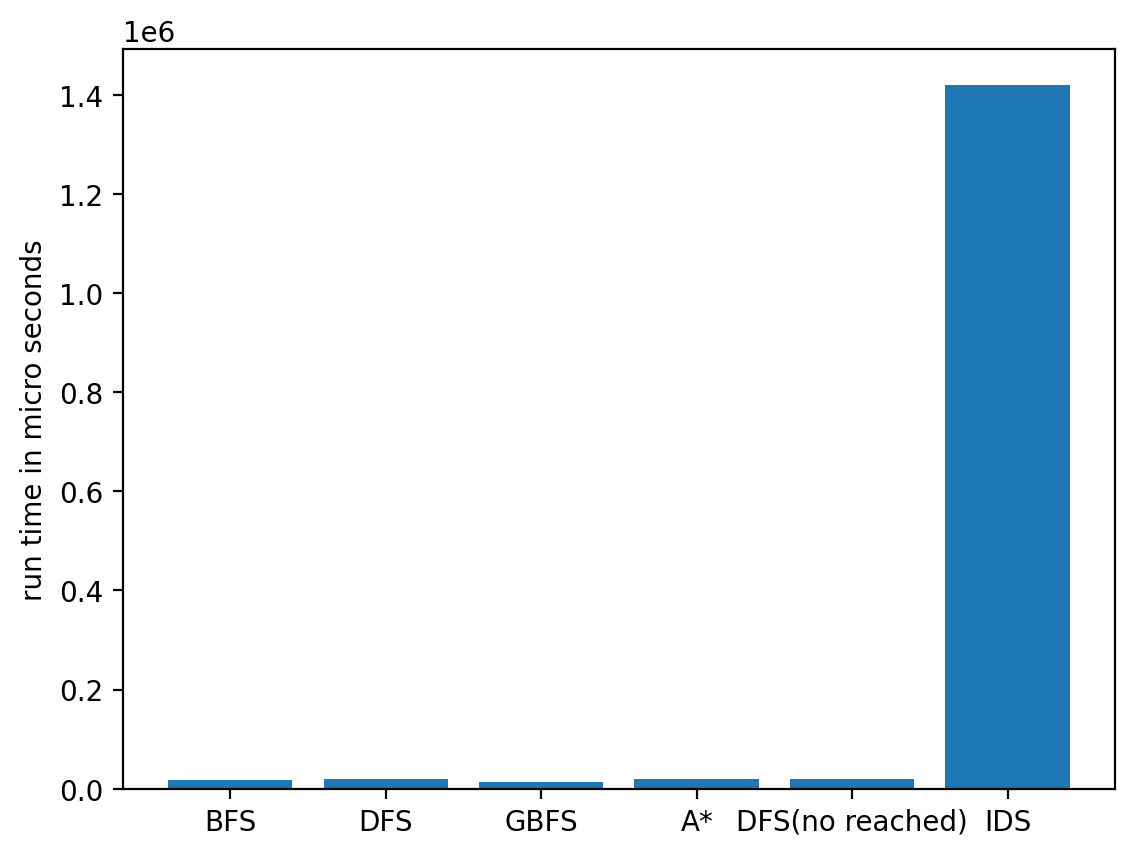

In [26]:
import matplotlib.pyplot as plt

plt.bar(df.columns, height = df.iloc[0])
plt.ylabel("run time in micro seconds")
plt.show()